In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.systems.framework import DiagramBuilder
from pydrake.multibody.parsing import Parser
import os
from pydrake.all import (
    LoadModelDirectives, ProcessModelDirectives, RevoluteJoint, 
    RationalForwardKinematics, CspaceFreePolytope, SeparatingPlaneOrder,
    RigidTransform, RotationMatrix, Rgba,
    AffineSubspace, MathematicalProgram, Solve,
    MeshcatVisualizer, StartMeshcat,
    LoadIrisRegionsYamlFile, ModelVisualizer
)
import numpy as np
# from pydrake.geometry.optimization_dev import (CspaceFreePolytope, SeparatingPlaneOrder)
from iris_plant_visualizer import IrisPlantVisualizer
from pydrake.geometry import Role
from pydrake.geometry.optimization import IrisOptions, HPolyhedron, Hyperellipsoid#, IrisInRationalConfigurationSpace
from pydrake.solvers import MosekSolver, CommonSolverOption, SolverOptions, ScsSolver
import time
from pgd import *

# set up the certifier and the options for different search techniques
solver_options = SolverOptions()
# set this to 1 if you would like to see the solver output in terminal.
solver_options.SetOption(CommonSolverOption.kPrintToConsole, 0)

os.environ["MOSEKLM_LICENSE_FILE"] = "/home/sgrg/mosek.lic"
with open(os.environ["MOSEKLM_LICENSE_FILE"], 'r') as f:
    contents = f.read()
    mosek_file_not_empty = contents != ''
print(mosek_file_not_empty)

solver_id = MosekSolver.id() if MosekSolver().available() and mosek_file_not_empty else ScsSolver.id()


solver_id = MosekSolver.id() if MosekSolver().available() else ScsSolver.id()
import logging
# dk_log = logging.getLogger("drake")
# dk_log.setLevel(logging.DEBUG)
# dk_log.getChild("Snopt").setLevel(logging.INFO)

True


In [3]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/clutter_ciris_scenario.dmd.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)
plant.Finalize()
meshcat = StartMeshcat()
MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
diagram = builder.Build()
q0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(context)
plant.SetPositions(plant_context, q0)
diagram.ForcedPublish(context)

INFO:drake:Meshcat listening for connections at http://localhost:7002


In [4]:
# vv = ModelVisualizer(browser_new=True)
# vv.parser().package_map().Add("ciris_pgd", os.path.abspath(''))
# vv.AddModels("/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_primitive_collision.urdf")
# vv.AddModels("/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_sphere_collision_complex_scenario.dmd.yaml")
# vv.Run()

In [5]:
q_low = np.array([-2.967060,-2.094395,-2.967060,-2.094395,-2.967060,-2.094395,-3.054326])
q_high = np.array([2.967060,2.094395,2.967060,2.094395,2.967060,2.094395,3.054326])
idx = 0
for joint_index in plant.GetJointIndices():
    joint = plant.get_mutable_joint(joint_index)
    if isinstance(joint, RevoluteJoint):
        joint.set_default_angle(q0[idx])
        joint.set_position_limits(lower_limits= np.array([q_low[idx]]), upper_limits= np.array([q_high[idx]]))
        print(joint)
        idx += 1 

<RevoluteJoint name='iiwa_joint_1' index=1 model_instance=2>
<RevoluteJoint name='iiwa_joint_2' index=2 model_instance=2>
<RevoluteJoint name='iiwa_joint_3' index=3 model_instance=2>
<RevoluteJoint name='iiwa_joint_4' index=4 model_instance=2>
<RevoluteJoint name='iiwa_joint_5' index=5 model_instance=2>
<RevoluteJoint name='iiwa_joint_6' index=6 model_instance=2>
<RevoluteJoint name='iiwa_joint_7' index=7 model_instance=2>


In [6]:
Ratfk = RationalForwardKinematics(plant)

# the point about which we will take the stereographic projections
# q_star = np.zeros(plant.num_positions())
q_star = np.array([0.0,0.0,0.0,0.0,0.0,0.0,0.0])
do_viz = True

# The object we will use to perform our certification.
cspace_free_polytope = CspaceFreePolytope(plant, scene_graph, SeparatingPlaneOrder.kAffine, q_star)

# # Define the source and destination directories
# regions_folder = '/home/sgrg/rlg/SUPERUROP/ciris/regions_real/'

# # os.makedirs(destination_dir, exist_ok=True)
# regions_dict = dict()
# # Iterate over all files in the regions directory
# for filename in os.listdir(regions_folder):
#     regions_dict.update(LoadIrisRegionsYamlFile(f"/home/sgrg/rlg/SUPERUROP/ciris/regions_real/{filename}"))
#     print(f'Region "{filename}" has been loaded')
# regions_dict = LoadIrisRegionsYamlFile(f"/home/sgrg/rlg/SUPERUROP/ciris/1121/connected_regions_first.yaml")

regions_dict = LoadIrisRegionsYamlFile(f"/home/sgrg/rlg/SUPERUROP/ciris/0205/simple_regions.yaml")

print('All regions have been loaded.')
regions = list(regions_dict.values())
print(list(regions_dict.keys()))

All regions have been loaded.
['top_0', 'top_1', 'top_10', 'top_11', 'top_12', 'top_13', 'top_14', 'top_15', 'top_16', 'top_17', 'top_18', 'top_19', 'top_2', 'top_3', 'top_4', 'top_5', 'top_6', 'top_7', 'top_8', 'top_9']


In [7]:
q_star

array([0., 0., 0., 0., 0., 0., 0.])

In [ ]:
Ratfk.ComputeSValue(mb_qs[-2], q_star), regions_dict['top_nom_connector'].ChebyshevCenter(), regions_dict['twisted_nom'].ChebyshevCenter()

In [ ]:
Ratfk.ComputeQValue(regions_dict['twisted_nom'].ChebyshevCenter(), q_star)

In [ ]:
q_star = np.array([0.0,0.0,0.0,0.0,0.0,0.0,0.0])

meshcat.AddButton("Stop")
meshcat.AddButton("Use")
meshcat.AddButton("Discard")
use_clicks, discard_clicks = 0, 0
rng = RandomGenerator(42)
Rs = regions_dict['top_15'].UniformSample(rng)
q = Ratfk.ComputeQValue(Rs, q_star)
# visualize it
plant_context = plant.GetMyContextFromRoot(context)
plant.SetPositions(plant_context, q)
diagram.ForcedPublish(context)
useful_qs = []

while meshcat.GetButtonClicks("Stop") < 1:
    # compute q
    # if we hit use as start point, save as start q.
    if meshcat.GetButtonClicks("Use") > use_clicks:
        start_q = q
        print(start_q)
        start_s = Rs
        useful_qs.append(start_q)
        use_clicks = meshcat.GetButtonClicks("Use")
    elif meshcat.GetButtonClicks("Discard") > discard_clicks:
        # sample a point from lbin
        Rs = regions_dict['top_15'].UniformSample(rng, Rs)
        q = Ratfk.ComputeQValue(Rs, q_star)
        # visualize it
        plant_context = plant.GetMyContextFromRoot(context)
        plant.SetPositions(plant_context, q)
        diagram.ForcedPublish(context)
        discard_clicks = meshcat.GetButtonClicks("Discard")
    time.sleep(0.01)

[ 1.29425637  0.81317196 -0.17509113 -0.77366718 -1.08266379  0.33523161
  3.03984701]


In [10]:
meshcat.DeleteButton("Stop")
meshcat.AddButton("Stop")
Rs = regions_dict['top_6'].UniformSample(rng)
q = Ratfk.ComputeQValue(Rs, q_star)
# visualize it
plant_context = plant.GetMyContextFromRoot(context)
plant.SetPositions(plant_context, q)
diagram.ForcedPublish(context)
end_useful_qs = []

while meshcat.GetButtonClicks("Stop") < 1:
    # compute q
    # if we hit use as start point, save as start q.
    if meshcat.GetButtonClicks("Use") > use_clicks:
        end_q = q
        print(end_q)
        end_s = Rs
        useful_qs.append(end_q)
        use_clicks = meshcat.GetButtonClicks("Use")
    elif meshcat.GetButtonClicks("Discard") > discard_clicks:
        # sample a point from lbin
        Rs = regions_dict['top_6'].UniformSample(rng, Rs)
        q = Ratfk.ComputeQValue(Rs, q_star)
        # visualize it
        plant_context = plant.GetMyContextFromRoot(context)
        plant.SetPositions(plant_context, q)
        diagram.ForcedPublish(context)
        discard_clicks = meshcat.GetButtonClicks("Discard")
    time.sleep(0.01)

In [173]:
meshcat.AddButton("Stop")
meshcat.AddButton("Use")
meshcat.AddButton("Discard")
use_clicks, discard_clicks = 0, 0
rng = RandomGenerator(42)
# Rs = regions_dict['lbin'].UniformSample(rng)
# q = Ratfk.ComputeQValue(Rs, q_star)
# visualize it
# plant_context = plant.GetMyContextFromRoot(context)
# plant.SetPositions(plant_context, q)
# diagram.ForcedPublish(context)
end_useful_qs = []
i = 0
while meshcat.GetButtonClicks("Stop") < 1:
    # compute q
    # if we hit use as start point, save as start q.
    if meshcat.GetButtonClicks("Use") > use_clicks:
        i += 1
        use_clicks = meshcat.GetButtonClicks("Use")
    elif meshcat.GetButtonClicks("Discard") > discard_clicks:
        # sample a point from lbin
#         Rs = regions_dict['lbin'].UniformSample(rng, Rs)
        print(i)
        q = rb_qs[i]
        # visualize it
        plant_context = plant.GetMyContextFromRoot(context)
        plant.SetPositions(plant_context, q)
        diagram.ForcedPublish(context)
        discard_clicks = meshcat.GetButtonClicks("Discard")
    time.sleep(0.01)

0
1
2
3
4
4
5
6
7
8
9
10
11
12
13
14
15
16
17


IndexError: list index out of range

In [148]:
sim_context = context
# 6, 8, 13, 15, 16, 23, 26
# 3, 6, 14, 15, 16

In [7]:
start_q = [ 1.29425637, 0.81317196, -0.17509113, -0.77366718, -1.08266379,  0.33523161,
  3.03984701]
 #[1.28958851, 0.86804369, -0.12931089, -0.64046585, -0.0116336, 0.23921351, 3.0399241]
end_q = regions_dict['top_0'].ChebyshevCenter()

start = Ratfk.ComputeSValue(start_q, q_star)
# start = regions_dict['nominal'].Intersection(regions_dict['top']).ChebyshevCenter()
goal = regions_dict['top_3'].ChebyshevCenter()#Ratfk.ComputeSValue(end_q, q_star)
# goal = regions_dict['twisted_rbin'].ChebyshevCenter()
for region in regions_dict:
    if regions_dict[region].PointInSet(start):
        print(region, " has point start")
    if regions_dict[region].PointInSet(goal):
        print(region, " has point goal")
#     else:print(region, "does not have goal")

top_15  has point start
top_3  has point goal


In [58]:
regions_dict

{'connector': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd8fd4a30>,
 'lbin': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd954cff0>,
 'mbin': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd954e030>,
 'nominal': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd954edb0>,
 'rbin1': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd954c3b0>,
 'rbin2': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd954f6b0>,
 'top': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdd796dd30>,
 'twisted_lbin': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdcb7db370>,
 'twisted_lbin2': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdcadc67b0>,
 'twisted_lbin_top': <pydrake.geometry.optimization.HPolyhedron at 0x7fcdcadc7d70>,
 'twisted_lbin_top2': <pydrake.geometry.optimization.HPolyhedron at 0x7fcde3925a70>,
 'twisted_mbin': <pydrake.geometry.optimization.HPolyhedron at 0x7fcde3926770>,
 'twisted_nom': <pydrake.geometry.optimization.HPolyhedron at 0x7fcde3924270>

In [7]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 0.1
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])

            t2 = time.perf_counter()

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [13]:
regions_dict

{'top_0': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f9606b0>,
 'top_1': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f960fb0>,
 'top_10': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f960470>,
 'top_11': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f9605b0>,
 'top_12': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f9604f0>,
 'top_13': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f960830>,
 'top_14': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f960970>,
 'top_15': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f960b30>,
 'top_16': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f961370>,
 'top_17': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f9613f0>,
 'top_18': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f9614b0>,
 'top_2': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f961570>,
 'top_3': <pydrake.geometry.optimization.HPolyhedron at 0x76e27f961630>,
 'top_4': <pydrake.geometry.optimization.H

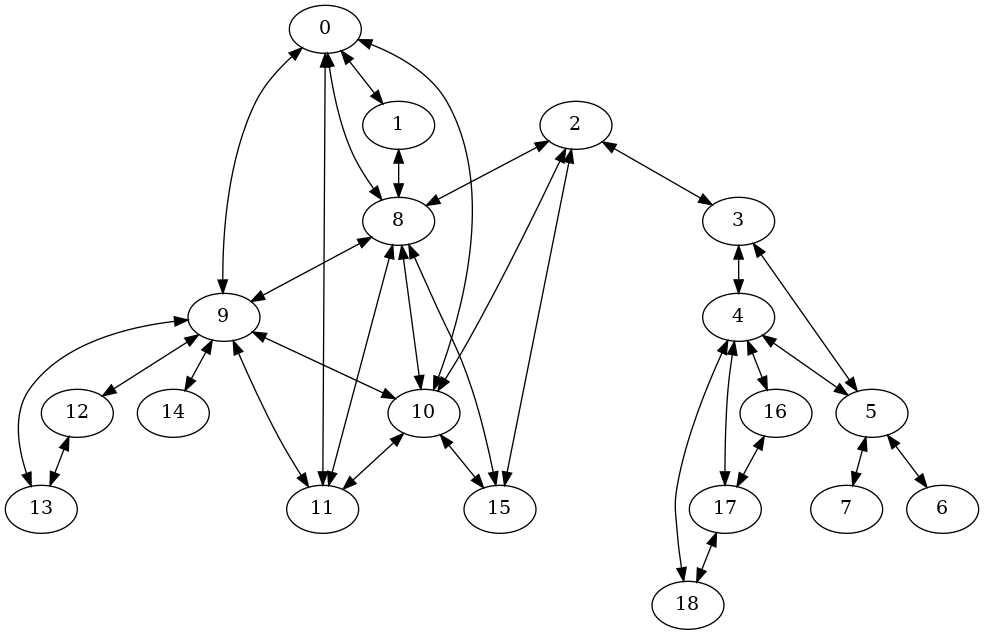

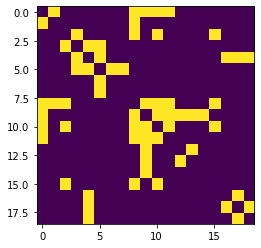

Graph has 1 connected components.


In [14]:
from util import notebook_plot_connectivity
notebook_plot_connectivity(regions, plot_dot=True, plot_adj_mat=True)

In [18]:
from IPython.display import display, Image, SVG
import pydot
s = gcs.GetGraphvizString()
display(
        Image(
            pydot.graph_from_dot_data(s)[0].create_png()
        )
    )


NameError: name 'gcs' is not defined

In [114]:
flows_result.is_success()

False

In [78]:
regions = list(regions_dict.values())

In [157]:
regions_dict['twisted_rbin'].IntersectsWith(regions_dict['top'])

True

In [12]:
samples = np.load('7dof_endpoints.npy')
pairs = [(samples[i], samples[-i-1]) for i in range(len(samples))]
start, goal = pairs[165]

In [21]:
order

5

In [8]:
ORDER = order
gcs, flows_result = generate_flows(start, goal, ORDER, regions, dim=7)
print("flow generated")
start_vertex, end_vertex = prune(gcs, flows_result, epsilon=0.00001)
print("pruned")
best_path, best_rounded_result = run_dfs(flows_result, gcs, start_vertex, end_vertex, iterations=5)

5 7


INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=false and preprocessing=true and no rounding.


flow generated
Start vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x732087136370>   and end vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x73206f79cb70>
pruned
True
found a successful path?
True
True
True
True
Cost for best path found   20.805534543265033


In [9]:
# # setup for PGD
variables, indices, h_list = generate_variable_list(best_path, ndim=7, order=ORDER)
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)

import numpy.linalg as la
# # iterate until infeasible.
# # get constraints and put into HPolyhedron - should be the same as 
prog, _ = prog_with_constraints(variables, best_path, start, goal, indices, 7, h_list)

In [10]:
print("program set")
hpoly = HPolyhedron(prog)
# is A necessary?
A = hpoly.A()
b = hpoly.b()
# create affine subspace
A_eq, b_eq = get_equality_matrices(prog)
U, S, V = la.svd(A_eq)

# nullspace is spanned by the last n-r columns of V
# rank is almost zero entries along the diagonal of S
r = (S>0.00001).sum()
basis = V[r:]
translation = la.pinv(A_eq).dot(b_eq)

affine_sub = AffineSubspace(basis.T, translation)

program set


## Running PGD

In [11]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
#         print("Getting gradients")
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)
#     print("got initial gradients and costs ", f_Rk, df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 10.0
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
#         print("in backtracking, f_k determined to be ", f_k, "Max optimal is", (f_Rk - 0.5*t*(L_norm)))
#         print("in backtracking, while condition is ", f_k > (f_Rk - 0.5*t*(L_norm)))
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
#             print("checkingwhat step to use f_k = ", f_k, "Will it work against ", f_Rk - 0.5*t*(L_norm))
            t2 = time.perf_counter()
        print('Found step size, ', t)

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [12]:
t1_start = perf_counter() 
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)
 
iters = 50
eps = 1e-7
qps_solved = 0
iter_costs = []
x_axis = []
times = []
t_grads = []
t_bt = []
t_qp = []
bt_costs = []
time_steps = []
lnorms = []
running_qp_project = []
termin = []
total_ts = []
costs_ts = []
qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, 7, h_list)
init_values, qp_c = run_qp_proj(variables, init_values, best_path, start, goal, indices, h_list, qp)
print('setup')

setup


In [13]:
from jax import grad
import jax
# define costfn
jax.clear_caches()
costfn = jax.jit(distance_for_vertex, backend="cpu")
t1 = perf_counter()
costfn(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
print("warm start costfn took ", t2 - t1)

Unable to load cuDNN. Is it installed?
Traceback (most recent call last):
  File "/home/sgrg/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 322, in _version_check
    version = get_version()
RuntimeError: cuDNN not found.
 (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


warm start costfn took  0.8108593850047328


In [14]:
grad_cost = grad(distance_for_vertex)
grad_jit = jax.jit(grad_cost, backend='cpu')
t1 = perf_counter()
grad_jit(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
t2 - t1

5.70934579900495

In [15]:
investigative_trajs = []
exp_avg = 0
moving_avg = 0
diff_termin = []
window = 5
i = 0
while (len(diff_termin)==0 or abs(diff_termin[-1])>0.0005) and i < 70:
    total_start = perf_counter()
    grad_time = perf_counter()
#     print('.')
#     bt_cost, bt_time, ts, l_norm = 0, 0, 0, 0
    print("old value", init_values)
    init_values[:len(variables)], bt_cost, bt_time, ts, l_norm = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.01, backtracking=True, ndim=7)
    print("EXPECTED COST", bt_cost)
    print("new value", init_values)
#     init_values[:len(variables)] = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.005, backtracking=False)
    grad_time_stop = perf_counter()
#     print(grad_time_stop - grad_time)
    #### NOT TIMED #####
    t_grads.append(grad_time_stop - grad_time)
    t_bt.append(bt_time)
    bt_costs.append(bt_cost)
    time_steps.append(ts)
    lnorms.append(l_norm)
    ## NOT TIMED FIN ##
    qp_time = perf_counter()
    cheap_proj = affine_sub.Projection(init_values)[1].T[0] # DOUBLE CHECK THE SHAPE OF THIS
    if not hpoly.PointInSet(cheap_proj):
        print("QP RUN")
        init_values, qp_c = run_qp_proj(variables, cheap_proj, best_path, start, goal, indices, h_list, qp, qp_c)
        qps_solved += 1
        running_qp_project.append(True)
    else:
        print("Cheap affine projection worked")
        init_values = cheap_proj
        running_qp_project.append(False)
    print("Post projection values", init_values)
    qp_time_stop = perf_counter()
    #### NOT TIMED #####
    t_qp.append(qp_time_stop - qp_time)
    cost = 0
    cost_calc_start = perf_counter()
    for v in range(len(best_path[1:-1])):
        cost += costfn(init_values[indices[v][0]:indices[v][1]])
        if cost!=cost:
            print(v, i)
    iter_costs.append(cost)
    if len(iter_costs) >= window:
        moving_avg_new = sum(iter_costs[-window:])/window
        termin.append(moving_avg_new)
        if moving_avg != 0:
            diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
        moving_avg = moving_avg_new
#     exp_avg_new = alpha * cost + (1-alpha) * exp_avg
#     exp_avg = exp_avg_new
#     if len(iter_costs) > 4:
#         moving_avg_new = sum(iter_costs[-5:])/5
#         termin.append(moving_avg_new)
#         diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
#         moving_avg = moving_avg_new
    cost_calc_stop = perf_counter()
    costs_ts.append(cost_calc_stop-cost_calc_start)
    x_axis.append(i)
    times.append(perf_counter()-t1_start)
    if i % 10 == 0:
#         qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, h_list)
        print("     ")
    print('.', end='')
    ## NOT TIMED FIN ##
    total_end = perf_counter()
    total_ts.append(total_end-total_start)
    i += 1
#     if i>70:
#         investigative_trajs.append(trajectorify_given_vars(best_path, init_values, indices))
#     else if i==79:
        
t1_stop = perf_counter() 
cost = 0
for v in range(len(best_path[1:-1])):
    cost += costfn(init_values[indices[v][0]:indices[v][1]])
times.append(perf_counter()-t1_start)
iter_costs.append(cost)
x_axis.append(i)

print("Solve time:", t1_stop - t1_start, "QPs run", qps_solved, "iteration_costs", iter_costs)

old value [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7532600198939414, 0.42854969843258056, -0.08603670065536478, -0.40669350605618215, -0.5928232074549902, 0.1679477113598341, 19.6412995814824, 0.7521290719324761, 0.4276063567201854, -0.08523025220134729, -0.4063879188037484, -0.5888926557914771, 0.16736135651970754, 19.64195919022126, 0.7509393622552277, 0.42661590022631785, -0.08438904273718353, -0.40606877267234676, -0.5847638776403384, 0.16674682818872497, 19.6426534572777, 0.741982377780827, 0.41998843105889305, -0.07740421513883798, -0.40616405408066747, -0.600182724270514, 0.16044429693710371, 19.645714636286066, 0.7368981500536103, 0.4152356453445669, -0.07093383186772258, -0.40624229677281437, -0.5493197395390897, 0.15965611971044374, 19.648963935223502, 0.7318139223288698, 0.410482859631727, -0.06446344859344207, -0.4063205394646241, -0.4984567548091624, 0.158867942480818

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7511030477930141, 0.4269721228486613, -0.08505146865776611, -0.40710686170463195, -0.5952110087761946, 0.16748718721543154, 19.641276550100486, 0.7507541959265003, 0.42642197391571723, -0.08340987053625042, -0.4071987638932525, -0.5913473584692276, 0.16665319029246048, 19.641936846399606, 0.7521836168708366, 0.42795262532733874, -0.0847079709127191, -0.4069513545354622, -0.5829452145577084, 0.1681864050535534, 19.642636266863878, 0.7434986122357429, 0.42284696381522546, -0.08245914897706594, -0.40663651437464343, -0.599883976145268, 0.1647244408842012, 19.646744413585868, 0.7371983995153274, 0.41687634692118264, -0.07351212460871132, -0.4069229295821792, -0.5519820111380008, 0.16200229564935237, 19.64991717727386, 0.7308981867953169, 0.4109057300283736, -0.06456510023980856, -0.40720934479029686, -0.5040800461313142, 

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7512271357099455, 0.42775668314939364, -0.08575248209106504, -0.4070803383586991, -0.5945354680597811, 0.16803989857010682, 19.64124607631596, 0.7501207354955706, 0.4261604631504648, -0.08353052976585487, -0.407218685188896, -0.591818003874552, 0.16660725296427, 19.641908224833184, 0.7526260235448266, 0.4283013035278136, -0.0848263694837852, -0.40716766680304817, -0.5826641649340836, 0.1684651504134427, 19.642621008184808, 0.7446840857244469, 0.423924198814029, -0.0846530734757678, -0.40650982369241406, -0.6004906452316122, 0.16615522595766705, 19.647319313057967, 0.7378176486869595, 0.41770996722621473, -0.07501219216304467, -0.4070277841319198, -0.553579088884492, 0.16306489927178694, 19.650447397860823, 0.7309512116497718, 0.411495735639375, -0.06537131084991998, -0.4075457445718959, -0.5066675325378149, 0.15997457

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7514873058721181, 0.42812207223653626, -0.0861889496641024, -0.4070768600142749, -0.5941501201024786, 0.16837125605014341, 19.64122579416744, 0.7495524935362561, 0.42587124176449226, -0.08388810342586482, -0.4071634445979017, -0.5921721781361368, 0.16670115146592945, 19.641888726398008, 0.7530164102495448, 0.4286860007522166, -0.08480529966503679, -0.40736623278555295, -0.5824414986154917, 0.1686388275533832, 19.64260953309821, 0.7458231911939077, 0.4248452770878343, -0.08621059455915407, -0.40633127025660065, -0.6011863514425496, 0.1670011437436777, 19.64787676117364, 0.7384818116254878, 0.41848979733576186, -0.0763406340917625, -0.4070381975253256, -0.5550320001407303, 0.16384988422826027, 19.650943586251895, 0.7311404320571703, 0.41213431758403973, -0.06647067362423377, -0.4077451247942234, -0.5088776488390679, 0.1

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7518056231785007, 0.42837558931304975, -0.08638000248960251, -0.4070352836163407, -0.5938866946117469, 0.1685394541792518, 19.641184062594448, 0.7490794166952213, 0.42564712782656494, -0.08432977759225734, -0.4070143074321001, -0.5924265331242649, 0.16683827129167553, 19.64184717428524, 0.7532133705472779, 0.428836697056226, -0.08465901955854524, -0.4074715836146114, -0.5824716409166704, 0.16865724316904387, 19.642609129371007, 0.7469290056960833, 0.4254617765191584, -0.08707418849396767, -0.40609264004170986, -0.6020301585465785, 0.16746337569543476, 19.648346015880044, 0.7392646718365046, 0.4191591885467612, -0.07725625199777886, -0.4070021159880858, -0.5564560436639833, 0.16442575856672717, 19.65139335529693, 0.7316003379773036, 0.41285660057581725, -0.06743831550106272, -0.40791159193520105, -0.510881928782034, 0.

...

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7538880099370462, 0.42892913992597653, -0.08621712819866523, -0.4071852630166286, -0.5932535724169847, 0.16859700460697336, 19.64065723300033, 0.7502493120710976, 0.42525453333476737, -0.08606558124387541, -0.40529144084069396, -0.5924380381717197, 0.1674449283944444, 19.64122418356393, 0.7541231384554512, 0.42960044067883185, -0.08444797347502508, -0.40838323842520113, -0.5840199326899655, 0.168658540135507, 19.642835124814685, 0.7526688099296789, 0.42727796729365675, -0.08822528028705746, -0.40537150161037, -0.6038177086330181, 0.16825341158395316, 19.6531842706077, 0.7456634906003257, 0.4212738743199045, -0.08048019551345577, -0.40577225366349545, -0.5628955754442073, 0.16581417946136098, 19.657131561148535, 0.7386581712709719, 0.41526978134640674, -0.07273511073984602, -0.40617300571678366, -0.5219734422554814, 0.

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7539087790039165, 0.42894782330451164, -0.0862300108999184, -0.4071946881379104, -0.5932509870801216, 0.16860334838823662, 19.64064943523627, 0.7502972716685689, 0.4252525083026068, -0.08608623298929471, -0.4052792655341656, -0.5924330860259711, 0.16744988878168332, 19.64121486304779, 0.7541610714606097, 0.4296371164850517, -0.08446890852166679, -0.4083964407182915, -0.584025741326528, 0.1686705777374049, 19.642835965107807, 0.7526558285016691, 0.4272325891772053, -0.0881944572191482, -0.40535677915424784, -0.6037207823094667, 0.16823348723769646, 19.65334516727279, 0.7457187513767048, 0.4212686844688766, -0.0804968927459667, -0.40575708572622543, -0.562909883106592, 0.16580979132965376, 19.657333599462167, 0.7387816742517375, 0.4153047797609008, -0.07279932827277777, -0.4061573922984303, -0.5220989839038335, 0.163386

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7539352829872629, 0.4289600951990904, -0.0862089387277528, -0.4071949843849707, -0.5932619650178232, 0.16860065584689765, 19.640634022277517, 0.7503611989742713, 0.4252416885882227, -0.08607065440121649, -0.4052555554735407, -0.5924412056767611, 0.1674453835481983, 19.64119632091654, 0.7541041390495462, 0.42956880966327105, -0.08450214464448924, -0.40837500833059875, -0.5841633402273192, 0.16863411411624873, 19.642857333013158, 0.752641250880215, 0.4270520744301473, -0.0878683862083262, -0.4052317392811783, -0.6037238219514655, 0.16811525966992308, 19.653417327136964, 0.7458135318255604, 0.42124253192679373, -0.0802829520530418, -0.4057271956128883, -0.5630700800931849, 0.16574440120153733, 19.65754758324514, 0.7389858127708417, 0.4154329894258173, -0.072697517897726, -0.4062226519461476, -0.5224163382357007, 0.163373

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7539483807285936, 0.42896469936144394, -0.08620734054203234, -0.40719934201744906, -0.5932779027531481, 0.16860132827906937, 19.640627574079204, 0.7504312344094147, 0.4252473926179935, -0.08601879015874225, -0.4052403187880722, -0.5924507982345923, 0.1674464018580485, 19.641188612503793, 0.7541733218522436, 0.4296722763911479, -0.08455041376907317, -0.40842371919244314, -0.5841465143653206, 0.16867723312773056, 19.64286365185414, 0.752712627113449, 0.4271980089074432, -0.08803179470874112, -0.40533038349283984, -0.6034466159133212, 0.16821408793015893, 19.653634292512393, 0.7459082734076122, 0.4213057090953148, -0.08051319323032292, -0.4057217813380562, -0.5629940578382653, 0.16581912626802106, 19.65782837103498, 0.739103919701767, 0.4154134092834222, -0.07299459175190559, -0.40611317918342754, -0.5225414997632863, 0.

Post projection values [0.7556827904288067, 0.4305782597699018, -0.0877699091251302, -0.40735828812507857, -0.6012415368395184, 0.16920337378394942, 19.639900727646637, 0.7539729469502718, 0.4289883845067585, -0.08622512948260837, -0.4072105665403267, -0.593277502780659, 0.16860796840411116, 19.640619202958323, 0.7504965131525735, 0.4252560821517092, -0.08602063119270588, -0.40522903226783524, -0.5924462386533568, 0.167453090614374, 19.641178440409146, 0.754195606126289, 0.42969879873326844, -0.0845952080680289, -0.4084339864278783, -0.5841841806945155, 0.16868586299576707, 19.642873861454294, 0.7527201340777381, 0.42717879035230116, -0.0879769931461889, -0.4053246673277577, -0.6033133736133973, 0.16820705316919451, 19.65379657006389, 0.745985182451403, 0.4213256793743996, -0.08053426659962491, -0.4057078401700665, -0.5630290069668994, 0.1658280124081353, 19.65807874536034, 0.7392502308250547, 0.41547256839683117, -0.07309154005306727, -0.4060910130125951, -0.5227446403205065, 0.163448

In [16]:
traj_pgd = trajectorify_given_vars(best_path, init_values, indices, ndim=7)
traj_og = trajectorify_given_vars(best_path, [best_rounded_result.GetSolution(x) for x in variables], indices, ndim=7)

In [31]:
samples = [traj_pgd.value(t)[-1] for t in np.linspace(0, traj_pgd.end_time(), 100)]
plt.plot(np.arange(len(samples)), samples)

NameError: name 'plt' is not defined

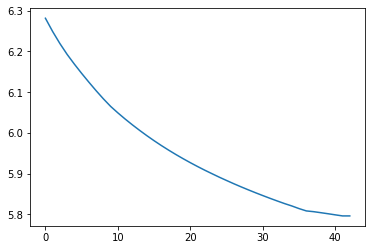

In [32]:
import matplotlib.pyplot as plt
plt.plot(np.arange(len(iter_costs)), iter_costs)

In [19]:
from util import remap_and_toppra_trajectory, build_env, plot_traj_end_effector_path
from pydrake.all import MultibodyPositionToGeometryPose, TrajectorySource, Simulator, InverseKinematics, PointCloud
import jaxutil as ju #from analytic_ik import Analytic_IK_7DoF, iiwa_alpha, iiwa_d, iiwa_limits_lower, iiwa_limits_upper
analytic_ik = ju.Analytic_IK_JAXLESS(ju.iiwa_alpha, ju.iiwa_d, ju.iiwa_limits_lower, ju.iiwa_limits_upper)

def remap(s):
    return Ratfk.ComputeQValue(s, q_star)

def plot_traj_end_effector_path(q_path, meshcat, name, diagram, plant, context, color_rgba=(1, 0, 0, 1)):
    points_local = []
    ee_frame = plant.GetFrameByName("iiwa_frame_ee")
    world_frame = plant.world_frame()
    
    for q in q_path:
        plant_context = plant.CreateDefaultContext()
        plant.SetPositions(plant_context, q)
        points_local.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())
        
    pointcloud = PointCloud(len(points_local))
    pointcloud.mutable_xyzs()[:] = np.asarray(points_local).T
    meshcat.SetObject("paths/" + name, pointcloud, 0.015, rgba=Rgba(*color_rgba))

gcs_traj_pgd = remap_and_toppra_trajectory(traj_pgd, remap, plant)
breaks_new = np.linspace(0, gcs_traj_pgd.end_time(), int(1e3), endpoint=False)
knots_full = gcs_traj_pgd.vector_values(breaks_new)

gcs_traj_og = remap_and_toppra_trajectory(traj_og, remap, plant)
breaks_new_og = np.linspace(0, gcs_traj_og.end_time(), int(1e3), endpoint=False)
knots_full_og = gcs_traj_og.vector_values(breaks_new_og)

# knots_full = np.array([remap(knot) for knot in knots_latent.T]).T

builder = DiagramBuilder()

subdiagram, plant, scene_graph = build_env(meshcat, directives_file, export_sg_input=True)
builder.AddNamedSystem("env_diagram", subdiagram)
pose_info = MultibodyPositionToGeometryPose(plant)
meshcat.SetCameraPose([-1.5, 0.5, 1.35], [0, 0.0, 0.0])
plot_traj_end_effector_path(knots_full.T, meshcat, "newpath", diagram, plant, context, color_rgba=(0, 0.2, 1, 1))
plot_traj_end_effector_path(knots_full_og.T, meshcat, "og", diagram, plant, context, color_rgba=(1, 0.2, 0, 1))

# plot_traj_end_effector_path(knots_full.T, meshcat, analytic_ik)
# plot_traj_end_effector_path(knots_full_og.T, meshcat, analytic_ik, name="og", color_rgba=(1, 1, 1, 1))
to_pose = builder.AddSystem(pose_info)
builder.Connect(to_pose.get_output_port(), subdiagram.GetInputPort("source_pose"))

traj_system = builder.AddSystem(TrajectorySource(gcs_traj_og))
builder.Connect(traj_system.get_output_port(), to_pose.get_input_port())

diagram = builder.Build()

meshcat_visual = diagram.GetSubsystemByName("env_diagram").GetSystems()[1]

In [18]:
simulator = Simulator(diagram)
meshcat_visual.StartRecording()
simulator.AdvanceTo(gcs_traj_og.end_time() + 0.1)
meshcat_visual.PublishRecording()

In [22]:
og_traj_len = np.sum(np.linalg.norm(knots_full[:,1:] - knots_full[:,:-1], axis=0))
new_traj_len = np.sum(np.linalg.norm(knots_full_og[:,1:] - knots_full_og[:,:-1], axis=0))
print("GCS Path Length: %f" % og_traj_len)
print("GCS + PGD Path Length: %f" % new_traj_len)

GCS Path Length: 3.733892
GCS + PGD Path Length: 3.698436


In [20]:
fname = "top_shelf_pgd.html"
with open(fname, "w") as f:
    f.write(meshcat.StaticHtml())

In [147]:
gcs_traj_og.end_time(), gcs_traj_pgd.end_time()

(6.24508918380631, 5.1055532066973575)

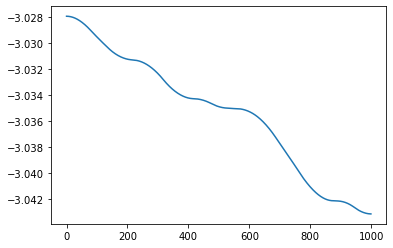

In [171]:
plt.plot(np.arange(len(knots_full_og.T)), [knot[-1] for knot in knots_full_og.T])

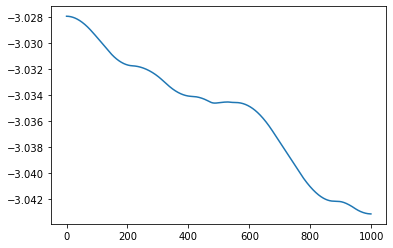

In [170]:
plt.plot(np.arange(len(knots_full_og.T)), [knot[-1] for knot in knots_full.T])

In [148]:
gcs_traj = remap_and_toppra_trajectory(traj, remap, plant)
breaks_new = np.linspace(0, gcs_traj.end_time(), int(1e3), endpoint=False)
knots_latent = gcs_traj.vector_values(breaks_new)

knots_full = np.array([remap(knot) for knot in knots_latent.T]).T

diagrams, plants = plot_traj_swept_volume(knots_full.T, build_env, meshcat, directives_file, count=2, alpha=0.15)
plot_traj_end_effector_path(knots_full.T,
                            meshcat,
                            analytic_ik)

meshcat.SetCameraPose([-1, 0.3825, 0.75], [0, 0.3825, 0.25])
render_trajectory(meshcat, build_env, directives_file, gcs_traj, save=True, fname="nonconvex_cost.html")

latent_traj_len = np.sum(np.linalg.norm(knots_latent[:,1:] - knots_latent[:,:-1], axis=0))
true_traj_len = np.sum(np.linalg.norm(knots_full[:,1:] - knots_full[:,:-1], axis=0))
print("GCS Latent Path Length: %f" % latent_traj_len)
print("GCS True Path Length: %f" % true_traj_len)

right_len = np.sum(np.linalg.norm(knots_full[7:,1:] - knots_full[7:,:-1], axis=0))
left_len = np.sum(np.linalg.norm(knots_full[:7,1:] - knots_full[:7,:-1], axis=0))
print(f"Arm 1 path length: {right_len}")
print(f"Arm 2 path length: {left_len}")
print(f"pretty metric: {(right_len-left_len)/left_len}")

reachability_errs = [reachability_constraint_violation(point[:7], point[7:], analytic_ik, FK_fun) for point in knots_full.T]
print("Maximum reachability distance error: %f" % np.max(reachability_errs))
plt.plot(reachability_errs)
plt.show()

with open(RepoDir() + "/data/q_full_path.pickle", "wb") as f:
    pickle.dump(knots_full.T, f)

NameError: name 'traj' is not defined

In [ ]:
len(best_path)

In [ ]:
# dumb init
pts = np.squeeze(np.array([np.arctan(traj.value(it * traj.end_time() / 100)) for it in range(100)]))

In [ ]:
# np.hstack([pts, 0 * np.ones((pts.shape[0], 3 - pts.shape[1]))]).T
pts.shape

In [98]:
# # visualize path given trajectory
import visualization_utils as viz_utils
# viz_utils.draw_traj(visualizer.meshcat_cspace, traj, 100)
# viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj, 100, q_star=q_star)
# visualizer.animate_traj_s(traj, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_og, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_og, 100, q_star=q_star)
visualizer.animate_traj_s(traj_og, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_pgd, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_pgd, 100, q_star=q_star)
visualizer.animate_traj_s(traj_pgd, 100, 100)

## Validating Paths?

In [106]:
# take a path
# calculate the q value at each point along the trajectory
# Sum all of them
def length_of_traj(traj):
    q_prev = start_q
    dist = 0
    for i in range(50):
        s = traj.value(traj.end_time()*i/50)
        q = Ratfk.ComputeQValue(s, q_star)
        dist += ((q - q_prev).dot(q - q_prev))**0.5
        q_prev = q
    return dist
new_len = length_of_traj(traj_pgd)
og_len = length_of_traj(traj_og)
print(new_len, og_len)

7.54364600906225 8.641229878292995


In [107]:
(og_len - new_len) / og_len

0.12701708954507795

In [108]:
q_star

array([0., 0., 0., 0., 0., 0., 0.])

In [109]:
traj_og.end_time()

2.0

In [110]:
traj_pgd.end_time()

2.0

In [56]:
iter_dist = 0
values = init_values
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [57]:
iter_dist

Array(3.3586519, dtype=float32)

In [58]:
iter_dist = 0
values = [best_rounded_result.GetSolution(x) for x in variables]
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [59]:
iter_dist

Array(3.3597455, dtype=float32)

In [99]:
q_star

array([1., 1.])

## 7 DOF IIWA

In [5]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_sphere_collision_complex_scenario.dmd.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)


# oneDOF_iiwa_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/oneDOF_iiwa7_with_box_collision.sdf"
# with open(one|DOF_iiwa_file, 'r') as f:
#     oneDOF_iiwa_string = f.read()
# box_asset_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/box_small.urdf"
# with open(box_asset_file, 'r') as f:
#     box_asset_string = f.read()

In [45]:
e = traj_og.end_time()
for i in range(100):
    print(traj_og.value(e*i/100))

[[-1.69549472e+00]
 [ 8.35285831e-01]
 [-2.32222896e-01]
 [-3.77592237e-01]
 [ 2.64490807e-01]
 [ 8.30988863e-01]
 [-9.35905537e-07]]
[[-1.66237428e+00]
 [ 8.17792917e-01]
 [-2.32156676e-01]
 [-4.01845435e-01]
 [ 2.52655238e-01]
 [ 8.01188546e-01]
 [-1.25616175e-03]]
[[-1.6340342 ]
 [ 0.80282381]
 [-0.23210015]
 [-0.42259789]
 [ 0.24252803]
 [ 0.77568924]
 [-0.00233022]]
[[-1.60966807]
 [ 0.78995247]
 [-0.23205172]
 [-0.44044009]
 [ 0.23382103]
 [ 0.75376535]
 [-0.00325369]]
[[-1.58850502]
 [ 0.77877155]
 [-0.23200986]
 [-0.45593648]
 [ 0.22625879]
 [ 0.73472326]
 [-0.00405577]]
[[-1.56982076]
 [ 0.7688983 ]
 [-0.23197318]
 [-0.46961738]
 [ 0.21958249]
 [ 0.71791124]
 [-0.00476391]]
[[-1.55294871]
 [ 0.75998039]
 [-0.23194035]
 [-0.48197087]
 [ 0.21355398]
 [ 0.7027295 ]
 [-0.00540339]]
[[-1.537291  ]
 [ 0.75170183]
 [-0.23191023]
 [-0.4934347 ]
 [ 0.20795961]
 [ 0.68864007]
 [-0.00599686]]
[[-1.52232957]
 [ 0.74378879]
 [-0.2318818 ]
 [-0.50438817]
 [ 0.20261429]
 [ 0.67517679]
 [-0.0

In [33]:
from pydrake.all import PointCloud

def visualise_IRIS(regions, plant, plant_context, seed=42, num_sample=10000, colors=None):       
    world_frame = plant.world_frame()
    ee_frame = plant.GetFrameByName("iiwa_frame_ee")

    rng = RandomGenerator(seed)

    # Allow caller to input custom colors
    if colors is None:
        colors = [
                    Rgba(0.5,0.0,0.0,0.5),
                    Rgba(0.0,0.5,0.0,0.5),
                    Rgba(0.0,0.0,0.5,0.5),
                    Rgba(0.5,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.5,0.5),
                    Rgba(0.2,0.2,0.2,0.5),
                    Rgba(0.5,0.2,0.0,0.5),
                    Rgba(0.2,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.2,0.5),
                    Rgba(0.2,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.2,0.5),
                    Rgba(0.0,0.2,0.5,0.5),
                ]

    for i in range(len(regions)):
        region = regions[i]

        xyzs = []  # List to hold XYZ positions of configurations in the IRIS region

        rq_sample = region.UniformSample(rng)
        q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

        plant.SetPositions(plant_context, q_sample)
        xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        for _ in range(num_sample-1):
            prev_sample = rq_sample
            rq_sample = region.UniformSample(rng, prev_sample)
            q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

            plant.SetPositions(plant_context, q_sample)
            xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        # Create pointcloud from sampled point in IRIS region in order to plot in Meshcat
        xyzs = np.array(xyzs)
        pc = PointCloud(len(xyzs))
        pc.mutable_xyzs()[:] = xyzs.T
        meshcat.SetObject(f"regions/region {i}", pc, point_size=0.025, rgba=colors[i % len(colors)])

In [50]:
visualise_IRIS([regions[6]], plant, plant_context)

In [51]:
regions[6]

In [52]:
regions_dict

{'lbin': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b353f0>,
 'mbin': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b345f0>,
 'nominal': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b34870>,
 'rbin1': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b35270>,
 'rbin2': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b35bb0>,
 'top': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b367b0>,
 'top_nom_connector': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b36bb0>,
 'twisted_lbin': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b370f0>,
 'twisted_mbin': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b37730>,
 'twisted_rbin': <pydrake.geometry.optimization.HPolyhedron at 0x7d99f4b37eb0>}

In [186]:
rng = RandomGenerator()
regions_dict['twisted_rbin'].Intersection(regions_dict['top']).CalcVolumeViaSampling(rng,)

TypeError: CalcVolumeViaSampling(): incompatible function arguments. The following argument types are supported:
    1. (self: pydrake.geometry.optimization.ConvexSet, generator: pydrake.common.RandomGenerator, desired_rel_accuracy: float = 0.01, max_num_samples: int = 10000.0) -> pydrake.geometry.optimization.SampledVolume

Invoked with: <pydrake.geometry.optimization.HPolyhedron object at 0x71d427121ef0>, <pydrake.common.RandomGenerator object at 0x71d40bc65330>

In [178]:
regions_dict['top'].CalcVolumeViaSampling(rng)

TypeError: CalcVolumeViaSampling(): incompatible function arguments. The following argument types are supported:
    1. (self: pydrake.geometry.optimization.ConvexSet, generator: pydrake.common.RandomGenerator, desired_rel_accuracy: float = 0.01, max_num_samples: int = 10000.0) -> pydrake.geometry.optimization.SampledVolume

Invoked with: <pydrake.geometry.optimization.HPolyhedron object at 0x71d483fc04b0>, <pydrake.common.RandomGenerator object at 0x71d40c35c930>

In [53]:
Ratfk.ComputeQValue(regions_dict['nominal'].Intersection(regions_dict['top']).ChebyshevCenter(), q_star)

array([ 0.49756563, -0.74235748, -1.06168504, -0.24552475,  0.30255693,
       -1.09002518,  2.90244339])